In [1]:
import pandas as pd

df = pd.read_csv("train.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (7613, 5)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [2]:
df.tail()

,id,keyword,location,text,target
7608,10869,NaN,NaN,Two giant cranes holding a bridge collapse int...,1
7609,10870,NaN,NaN,@aria_ahrary @TheTawniest The out of control w...,1
7610,10871,NaN,NaN,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,1
7611,10872,NaN,NaN,Police investigating after an e-bike collided ...,1
7612,10873,NaN,NaN,The Latest: More Homes Razed by Northern Calif...,1


In [3]:
print("Dataset Information:")
print("-" * 50)

df.info()

Dataset Information:
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


In [4]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
id             0
keyword       61
location    2533
text           0
target         0
dtype: int64


In [5]:
print("Number of duplicate rows:", df.duplicated().sum())
print("Number of duplicate tweets:", df["text"].duplicated().sum())

Number of duplicate rows: 0
Number of duplicate tweets: 110


In [6]:
print("Target Distribution:")
print(df["target"].value_counts())

print("\nTarget Percentage:")
print(df["target"].value_counts(normalize=True) * 100)

Target Distribution:
target
0    4342
1    3271
Name: count, dtype: int64

Target Percentage:
target
0    57.034021
1    42.965979
Name: proportion, dtype: float64


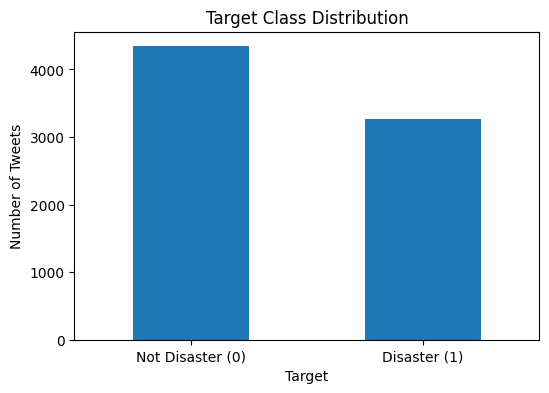

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

df["target"].value_counts().sort_index().plot(kind="bar")

plt.title("Target Class Distribution")
plt.xlabel("Target")
plt.ylabel("Number of Tweets")
plt.xticks([0, 1], ["Not Disaster (0)", "Disaster (1)"], rotation=0)
plt.show()

In [8]:
df["tweet_length"] = df["text"].apply(len)

print("Tweet Length Statistics:")
print(df["tweet_length"].describe())

Tweet Length Statistics:
count    7613.000000
mean      101.037436
std        33.781325
min         7.000000
25%        78.000000
50%       107.000000
75%       133.000000
max       157.000000
Name: tweet_length, dtype: float64


In [9]:
print("Average Tweet Length by Target:")
print(df.groupby("target")["tweet_length"].mean())

print("\nMedian Tweet Length by Target:")
print(df.groupby("target")["tweet_length"].median())

Average Tweet Length by Target:
target
0     95.706817
1    108.113421
Name: tweet_length, dtype: float64

Median Tweet Length by Target:
target
0    101.0
1    115.0
Name: tweet_length, dtype: float64


<Figure size 800x500 with 0 Axes>

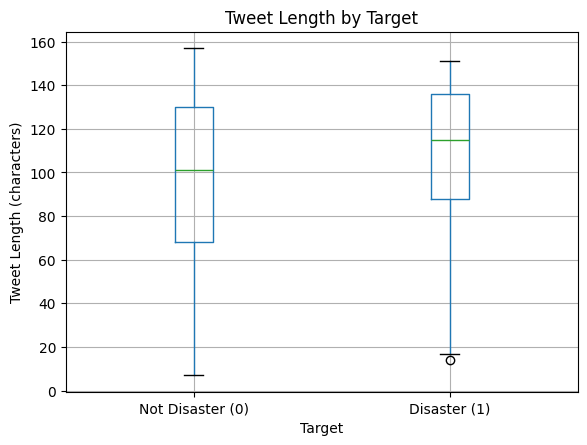

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

df.boxplot(column="tweet_length", by="target")

plt.title("Tweet Length by Target")
plt.suptitle("")
plt.xlabel("Target")
plt.ylabel("Tweet Length (characters)")
plt.xticks([1, 2], ["Not Disaster (0)", "Disaster (1)"])

plt.show()

In [11]:
df["word_count"] = df["text"].apply(lambda x: len(x.split()))

print("Word Count Statistics:")
print(df["word_count"].describe())

Word Count Statistics:
count    7613.000000
mean       14.903586
std         5.732604
min         1.000000
25%        11.000000
50%        15.000000
75%        19.000000
max        31.000000
Name: word_count, dtype: float64


In [12]:
print("Average Word Count by Target:")
print(df.groupby("target")["word_count"].mean())

print("\nMedian Word Count by Target:")
print(df.groupby("target")["word_count"].median())

Average Word Count by Target:
target
0    14.704744
1    15.167533
Name: word_count, dtype: float64

Median Word Count by Target:
target
0    15.0
1    15.0
Name: word_count, dtype: float64


<Figure size 800x500 with 0 Axes>

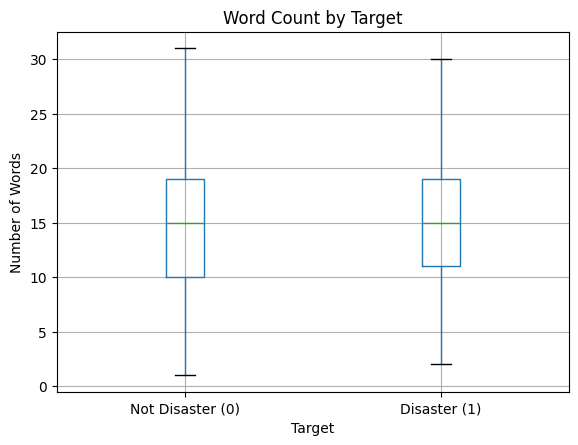

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

df.boxplot(column="word_count", by="target")

plt.title("Word Count by Target")
plt.suptitle("")
plt.xlabel("Target")
plt.ylabel("Number of Words")
plt.xticks([1, 2], ["Not Disaster (0)", "Disaster (1)"])

plt.show()

In [14]:
from collections import Counter

# Combine all tweet text
all_words = " ".join(df["text"]).split()

# Count word frequencies
word_freq = Counter(all_words)

# Display the 20 most common words
print("Top 20 Most Frequent Words:")
print(word_freq.most_common(20))


Top 20 Most Frequent Words:
[('the', 2575), ('a', 1845), ('to', 1805), ('in', 1757), ('of', 1722), ('and', 1302), ('I', 1197), ('for', 820), ('is', 814), ('on', 773), ('-', 763), ('you', 632), ('The', 552), ('my', 549), ('with', 508), ('that', 492), ('at', 485), ('by', 469), ('it', 433), ('from', 372)]


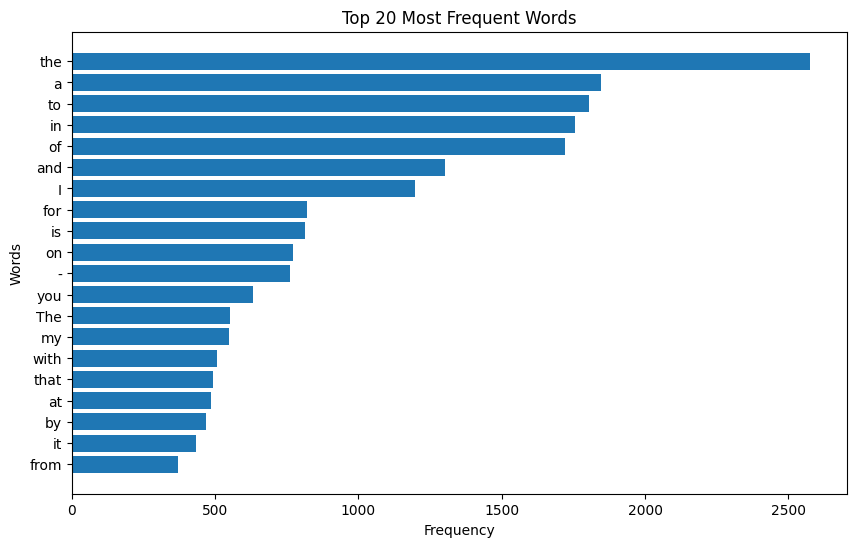

In [15]:
import matplotlib.pyplot as plt

top_words = word_freq.most_common(20)

words = [word for word, count in top_words]
counts = [count for word, count in top_words]

plt.figure(figsize=(10, 6))
plt.barh(words[::-1], counts[::-1])

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Words")

plt.show()


In [16]:
import re
import string

In [17]:
def clean_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Remove mentions
    text = re.sub(r"@\w+", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation and special characters
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [18]:
df["cleaned_text"] = df["text"].apply(clean_text)

df[["text", "cleaned_text"]].head()

,text,cleaned_text
0,Our Deeds are the Reason of this #earthquake M...,our deeds are the reason of this earthquake ma...
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada
2,All residents asked to 'shelter in place' are ...,all residents asked to shelter in place are be...
3,"13,000 people receive #wildfires evacuation or...",people receive wildfires evacuation orders in ...
4,Just got sent this photo from Ruby #Alaska as ...,just got sent this photo from ruby alaska as s...


In [19]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

In [20]:
def stem_text(text):
    words = text.split()
    stemmed_words = [stemmer.stem(word) for word in words]
    return " ".join(stemmed_words)

In [21]:
df["stemmed_text"] = df["cleaned_text"].apply(stem_text)

df[["cleaned_text", "stemmed_text"]].head()

,cleaned_text,stemmed_text
0,our deeds are the reason of this earthquake ma...,our deed are the reason of thi earthquak may a...
1,forest fire near la ronge sask canada,forest fire near la rong sask canada
2,all residents asked to shelter in place are be...,all resid ask to shelter in place are be notif...
3,people receive wildfires evacuation orders in ...,peopl receiv wildfir evacu order in california
4,just got sent this photo from ruby alaska as s...,just got sent thi photo from rubi alaska as sm...


In [22]:
import nltk

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [23]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def preprocess_text(text):
    # Step 1: Cleaning
    text = clean_text(text)

    # Step 2: Tokenization
    words = text.split()

    # Step 3: Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Step 4: Stemming
    words = [stemmer.stem(word) for word in words]

    # Step 5: Join words
    return " ".join(words)

In [24]:
df["processed_text"] = df["text"].apply(preprocess_text)

df[["text", "processed_text"]].head()

,text,processed_text
0,Our Deeds are the Reason of this #earthquake M...,deed reason earthquak may allah forgiv us
1,Forest fire near La Ronge Sask. Canada,forest fire near la rong sask canada
2,All residents asked to 'shelter in place' are ...,resid ask shelter place notifi offic evacu she...
3,"13,000 people receive #wildfires evacuation or...",peopl receiv wildfir evacu order california
4,Just got sent this photo from Ruby #Alaska as ...,got sent photo rubi alaska smoke wildfir pour ...


In [25]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df["target_encoded"] = label_encoder.fit_transform(df["target"])

print("Original classes:", label_encoder.classes_)
print("Encoded classes:", sorted(df["target_encoded"].unique()))

df[["target", "target_encoded"]].head()

Original classes: [0 1]
Encoded classes: [np.int64(0), np.int64(1)]


,target,target_encoded
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1


In [26]:
from collections import Counter

# Combine all processed tweets
processed_words = " ".join(df["processed_text"]).split()

# Count word frequencies
processed_word_freq = Counter(processed_words)

# Display top 20 processed words
print("Top 20 Processed Words:")
print(processed_word_freq.most_common(20))

Top 20 Processed Words:
[('like', 408), ('fire', 358), ('get', 311), ('im', 300), ('amp', 300), ('bomb', 231), ('new', 224), ('via', 220), ('one', 205), ('peopl', 198), ('go', 198), ('news', 195), ('dont', 191), ('burn', 178), ('kill', 176), ('time', 175), ('video', 174), ('us', 170), ('flood', 167), ('emerg', 163)]


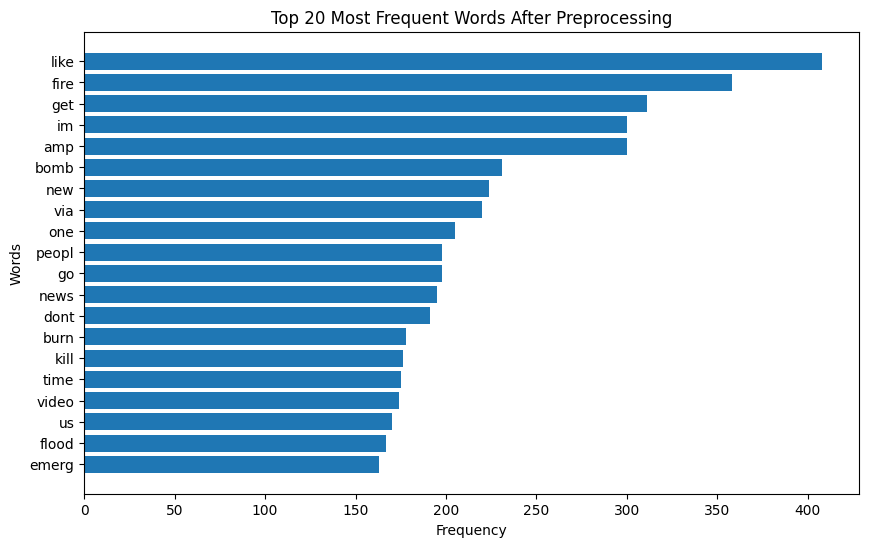

In [27]:
import matplotlib.pyplot as plt

top_processed_words = processed_word_freq.most_common(20)

words = [word for word, count in top_processed_words]
counts = [count for word, count in top_processed_words]

plt.figure(figsize=(10, 6))
plt.barh(words[::-1], counts[::-1])

plt.title("Top 20 Most Frequent Words After Preprocessing")
plt.xlabel("Frequency")
plt.ylabel("Words")

plt.show()

In [28]:
from sklearn.model_selection import train_test_split

X = df["processed_text"]
y = df["target_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 6090
Testing samples: 1523


In [29]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer()

X_train_count = count_vectorizer.fit_transform(X_train)
X_test_count = count_vectorizer.transform(X_test)

print("Training matrix shape:", X_train_count.shape)
print("Testing matrix shape:", X_test_count.shape)
print("Vocabulary size:", len(count_vectorizer.vocabulary_))

Training matrix shape: (6090, 10362)
Testing matrix shape: (1523, 10362)
Vocabulary size: 10362


In [30]:
from sklearn.feature_extraction.text import CountVectorizer

# Different CountVectorizer configurations
vectorizer_configs = {
    "Unigram": CountVectorizer(
        ngram_range=(1, 1)
    ),

    "Unigram + Bigram": CountVectorizer(
        ngram_range=(1, 2)
    ),

    "Tuned": CountVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_features=10000
    )
}

for name, vectorizer in vectorizer_configs.items():
    X_temp = vectorizer.fit_transform(X_train)

    print(f"{name}:")
    print("  Matrix shape:", X_temp.shape)
    print("  Vocabulary size:", len(vectorizer.vocabulary_))
    print()

Unigram:
  Matrix shape: (6090, 10362)
  Vocabulary size: 10362

Unigram + Bigram:
  Matrix shape: (6090, 46329)
  Vocabulary size: 46329

Tuned:
  Matrix shape: (6090, 8706)
  Vocabulary size: 8706



In [31]:
count_vectorizer = CountVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_features=10000
)

X_train_count = count_vectorizer.fit_transform(X_train)
X_test_count = count_vectorizer.transform(X_test)

print("Final CountVectorizer:")
print("Training shape:", X_train_count.shape)
print("Testing shape:", X_test_count.shape)
print("Vocabulary size:", len(count_vectorizer.vocabulary_))

Final CountVectorizer:
Training shape: (6090, 8706)
Testing shape: (1523, 8706)
Vocabulary size: 8706


In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_features=10000
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("TF-IDF Training shape:", X_train_tfidf.shape)
print("TF-IDF Testing shape:", X_test_tfidf.shape)
print("TF-IDF Vocabulary size:", len(tfidf_vectorizer.vocabulary_))

TF-IDF Training shape: (6090, 8706)
TF-IDF Testing shape: (1523, 8706)
TF-IDF Vocabulary size: 8706


In [33]:
!wget -q https://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip

In [34]:
import numpy as np

embedding_dim = 100

embeddings_index = {}

with open("glove.6B.100d.txt", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = vector

print("Number of GloVe words:", len(embeddings_index))
print("Embedding dimension:", embedding_dim)

Number of GloVe words: 400000
Embedding dimension: 100


In [35]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(
    num_words=10000,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

print("Vocabulary size:", len(tokenizer.word_index))

Vocabulary size: 10555


In [36]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

print("First training sequence:")
print(X_train_seq[0])

print("\nFirst test sequence:")
print(X_test_seq[0])

First training sequence:
[3178, 118, 219, 528, 3179, 2068, 3180, 729, 580, 3181, 3182, 3183]

First test sequence:
[1192, 10, 4, 129, 102, 1, 1]


In [37]:
import numpy as np

sequence_lengths = [len(seq) for seq in X_train_seq]

print("Maximum sequence length:", max(sequence_lengths))
print("Average sequence length:", np.mean(sequence_lengths))
print("Median sequence length:", np.median(sequence_lengths))
print("95th percentile:", np.percentile(sequence_lengths, 95))

Maximum sequence length: 23
Average sequence length: 8.811986863711002
Median sequence length: 9.0
95th percentile: 14.0


In [38]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_length = 23

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

print("Training padded shape:", X_train_pad.shape)
print("Testing padded shape:", X_test_pad.shape)

Training padded shape: (6090, 23)
Testing padded shape: (1523, 23)


In [39]:
vocab_size = min(10000, len(tokenizer.word_index) + 1)

embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, index in tokenizer.word_index.items():
    if index >= vocab_size:
        continue

    embedding_vector = embeddings_index.get(word)

    if embedding_vector is not None:
        embedding_matrix[index] = embedding_vector

print("Embedding matrix shape:", embedding_matrix.shape)

# Count words that have GloVe vectors
words_with_vectors = np.sum(np.any(embedding_matrix != 0, axis=1))

print("Words found in GloVe:", words_with_vectors)
print("Words not found in GloVe:", vocab_size - words_with_vectors)

Embedding matrix shape: (10000, 100)
Words found in GloVe: 6096
Words not found in GloVe: 3904


In [40]:
from sklearn.naive_bayes import MultinomialNB

nb_dtm = MultinomialNB()

nb_dtm.fit(X_train_count, y_train)

print("Naive Bayes DTM model trained successfully!")

Naive Bayes DTM model trained successfully!


In [41]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predictions
y_pred_nb_dtm = nb_dtm.predict(X_test_count)

# Accuracy
accuracy_nb_dtm = accuracy_score(y_test, y_pred_nb_dtm)

print("Naive Bayes (DTM) Accuracy:", accuracy_nb_dtm)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_nb_dtm,
    target_names=["Not Disaster", "Disaster"]
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb_dtm))

Naive Bayes (DTM) Accuracy: 0.8161523309258043

Classification Report:
              precision    recall  f1-score   support

Not Disaster       0.80      0.90      0.85       869
    Disaster       0.84      0.71      0.77       654

    accuracy                           0.82      1523
   macro avg       0.82      0.80      0.81      1523
weighted avg       0.82      0.82      0.81      1523

Confusion Matrix:
[[780  89]
 [191 463]]


In [42]:
nb_tfidf = MultinomialNB()

nb_tfidf.fit(X_train_tfidf, y_train)

print("Naive Bayes TF-IDF model trained successfully!")

Naive Bayes TF-IDF model trained successfully!


In [43]:
# Make predictions
y_pred_nb_tfidf = nb_tfidf.predict(X_test_tfidf)

# Accuracy
accuracy_nb_tfidf = accuracy_score(y_test, y_pred_nb_tfidf)

print("Naive Bayes (TF-IDF) Accuracy:", accuracy_nb_tfidf)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_nb_tfidf,
    target_names=["Not Disaster", "Disaster"]
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb_tfidf))

Naive Bayes (TF-IDF) Accuracy: 0.81483913328956

Classification Report:
              precision    recall  f1-score   support

Not Disaster       0.79      0.93      0.85       869
    Disaster       0.88      0.66      0.75       654

    accuracy                           0.81      1523
   macro avg       0.83      0.80      0.80      1523
weighted avg       0.82      0.81      0.81      1523

Confusion Matrix:
[[808  61]
 [221 433]]


In [44]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_tfidf, y_train)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [45]:
# Make predictions
y_pred_xgb = xgb_model.predict(X_test_tfidf)

# Accuracy
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)

print("XGBoost Accuracy:", accuracy_xgb)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=["Not Disaster", "Disaster"]
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost Accuracy: 0.7767564018384767

Classification Report:
              precision    recall  f1-score   support

Not Disaster       0.76      0.90      0.82       869
    Disaster       0.82      0.62      0.70       654

    accuracy                           0.78      1523
   macro avg       0.79      0.76      0.76      1523
weighted avg       0.78      0.78      0.77      1523

Confusion Matrix:
[[779  90]
 [250 404]]


In [46]:
results = pd.DataFrame({
    "Model": [
        "Naive Bayes - DTM",
        "Naive Bayes - TF-IDF",
        "XGBoost - TF-IDF"
    ],
    "Accuracy": [
        accuracy_nb_dtm,
        accuracy_nb_tfidf,
        accuracy_xgb
    ]
})

results = results.sort_values("Accuracy", ascending=False).reset_index(drop=True)

print(results)

                  Model  Accuracy
0     Naive Bayes - DTM  0.816152
1  Naive Bayes - TF-IDF  0.814839
2      XGBoost - TF-IDF  0.776756


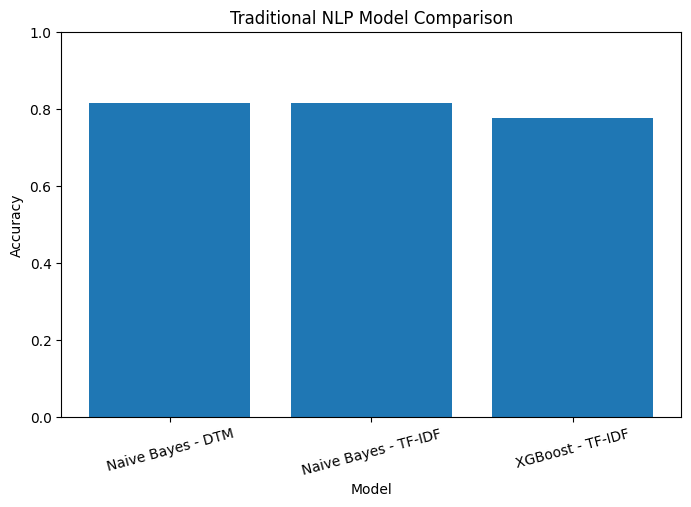

In [47]:
plt.figure(figsize=(8, 5))

plt.bar(results["Model"], results["Accuracy"])

plt.title("Traditional NLP Model Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)

plt.ylim(0, 1)
plt.show()

In [48]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [49]:
lstm_model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_length,
        trainable=False
    ),

    LSTM(64),

    Dropout(0.5),

    Dense(32, activation="relu"),

    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

In [50]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history_lstm = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.7063 - loss: 0.5807 - val_accuracy: 0.7709 - val_loss: 0.5005
Epoch 2/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7674 - loss: 0.5007 - val_accuracy: 0.7709 - val_loss: 0.4952
Epoch 3/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7826 - loss: 0.4830 - val_accuracy: 0.7537 - val_loss: 0.5099
Epoch 4/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7939 - loss: 0.4606 - val_accuracy: 0.7857 - val_loss: 0.4711
Epoch 5/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8064 - loss: 0.4435 - val_accuracy: 0.7767 - val_loss: 0.4736
Epoch 6/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8200 - loss: 0.4325 - val_accuracy: 0.7931 - val_loss: 0.4692
Epoch 7/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8342 - loss: 0.4021 - val_accuracy: 0.7865 - val_loss: 0.4762
Epoch 8/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8411 - loss: 0.3801 - val_accuracy:

In [51]:
# Evaluate on test data
lstm_test_loss, lstm_test_accuracy = lstm_model.evaluate(
    X_test_pad,
    y_test,
    verbose=0
)

print("LSTM Test Loss:", lstm_test_loss)
print("LSTM Test Accuracy:", lstm_test_accuracy)

LSTM Test Loss: 0.4471270740032196
LSTM Test Accuracy: 0.803676962852478


In [52]:
# Predict probabilities
y_pred_lstm_prob = lstm_model.predict(X_test_pad)

# Convert probabilities to classes
y_pred_lstm = (y_pred_lstm_prob >= 0.5).astype(int).ravel()

print("Classification Report:")
print(classification_report(
    y_test,
    y_pred_lstm,
    target_names=["Not Disaster", "Disaster"]
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lstm))

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Classification Report:
              precision    recall  f1-score   support

Not Disaster       0.79      0.89      0.84       869
    Disaster       0.82      0.69      0.75       654

    accuracy                           0.80      1523
   macro avg       0.81      0.79      0.79      1523
weighted avg       0.81      0.80      0.80      1523

Confusion Matrix:
[[770  99]
 [200 454]]


In [53]:
!pip install -q transformers

In [54]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cu128
CUDA available: True


In [55]:
from sklearn.model_selection import train_test_split

bert_texts = df["text"].tolist()
bert_labels = df["target_encoded"].tolist()

bert_train_texts, bert_val_texts, bert_train_labels, bert_val_labels = train_test_split(
    bert_texts,
    bert_labels,
    test_size=0.2,
    random_state=42,
    stratify=bert_labels
)

print("BERT training samples:", len(bert_train_texts))
print("BERT validation samples:", len(bert_val_texts))

BERT training samples: 6090
BERT validation samples: 1523


In [56]:
from transformers import AutoTokenizer

bert_model_name = "distilbert-base-uncased"

bert_tokenizer = AutoTokenizer.from_pretrained(bert_model_name)

print("BERT tokenizer loaded successfully!")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

BERT tokenizer loaded successfully!


In [57]:
def tokenize_data(texts):
    return bert_tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=128
    )

train_encodings = tokenize_data(bert_train_texts)
val_encodings = tokenize_data(bert_val_texts)

print("Tokenization completed!")
print("Training input shape:", len(train_encodings["input_ids"]))
print("Validation input shape:", len(val_encodings["input_ids"]))

Tokenization completed!
Training input shape: 6090
Validation input shape: 1523


In [58]:
from torch.utils.data import Dataset

class DisasterTweetDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)


train_dataset = DisasterTweetDataset(
    train_encodings,
    bert_train_labels
)

val_dataset = DisasterTweetDataset(
    val_encodings,
    bert_val_labels
)

print("Training dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))

Training dataset size: 6090
Validation dataset size: 1523


In [59]:
from transformers import AutoModelForSequenceClassification

bert_model = AutoModelForSequenceClassification.from_pretrained(
    bert_model_name,
    num_labels=2
)

print("DistilBERT model loaded successfully!")

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT model loaded successfully!


In [60]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    predictions = predictions.argmax(axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary"
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [61]:
training_args = TrainingArguments(
    output_dir="./bert_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_dir="./bert_logs",
    logging_steps=50,
    report_to="none"
)

print("BERT training configuration created!")

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


BERT training configuration created!


In [62]:
trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print("BERT Trainer created successfully!")

BERT Trainer created successfully!


In [63]:
bert_train_result = trainer.train()

print("BERT training completed!")

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.452478,0.380301,0.839790,0.852234,0.758410,0.802589
2,0.356014,0.411613,0.835194,0.805766,0.811927,0.808835
3,0.241877,0.440019,0.833224,0.815457,0.790520,0.802795


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BERT training completed!


In [65]:
bert_results = trainer.evaluate()

print("BERT Evaluation Results:")

for key, value in bert_results.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.241877,0.411613,3,0.835194,0.805766,0.811927,0.808835


BERT Evaluation Results:
eval_loss: 0.4116
eval_accuracy: 0.8352
eval_precision: 0.8058
eval_recall: 0.8119
eval_f1: 0.8088


In [66]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Get predictions
predictions = trainer.predict(val_dataset)

# Convert logits to predicted classes
y_pred_bert = np.argmax(predictions.predictions, axis=1)

# Classification report
print("BERT Classification Report:")
print(
    classification_report(
        bert_val_labels,
        y_pred_bert,
        target_names=["Not Disaster", "Disaster"]
    )
)

# Confusion matrix
print("BERT Confusion Matrix:")
print(confusion_matrix(bert_val_labels, y_pred_bert))

BERT Classification Report:
              precision    recall  f1-score   support

Not Disaster       0.86      0.85      0.86       869
    Disaster       0.81      0.81      0.81       654

    accuracy                           0.84      1523
   macro avg       0.83      0.83      0.83      1523
weighted avg       0.84      0.84      0.84      1523

BERT Confusion Matrix:
[[741 128]
 [123 531]]


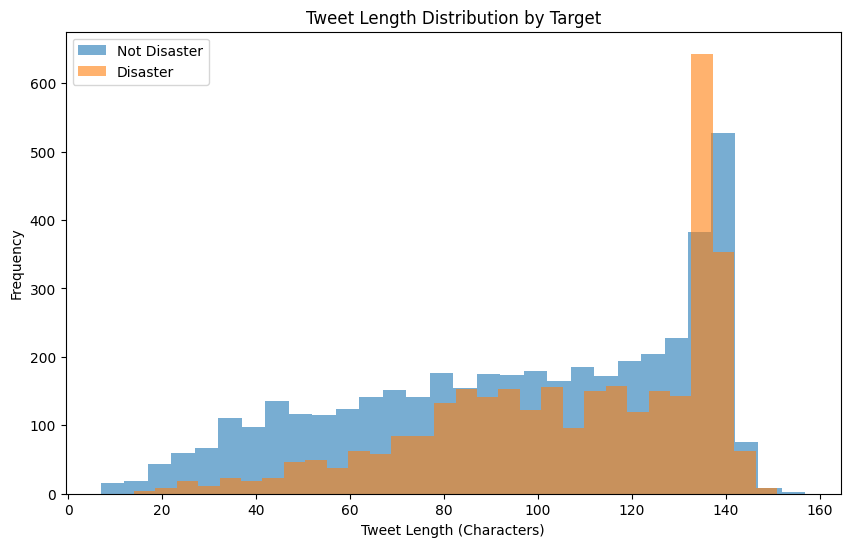

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(
    df[df["target"] == 0]["tweet_length"],
    bins=30,
    alpha=0.6,
    label="Not Disaster"
)

plt.hist(
    df[df["target"] == 1]["tweet_length"],
    bins=30,
    alpha=0.6,
    label="Disaster"
)

plt.title("Tweet Length Distribution by Target")
plt.xlabel("Tweet Length (Characters)")
plt.ylabel("Frequency")
plt.legend()

plt.show()

In [68]:
print("Original text:")
print(df["text"].iloc[0])

print("\nProcessed text:")
print(df["processed_text"].iloc[0])

print("\nMissing processed texts:")
print(df["processed_text"].isnull().sum())

Original text:
Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all

Processed text:
deed reason earthquak may allah forgiv us

Missing processed texts:
0


In [69]:
!pip install -q wordcloud

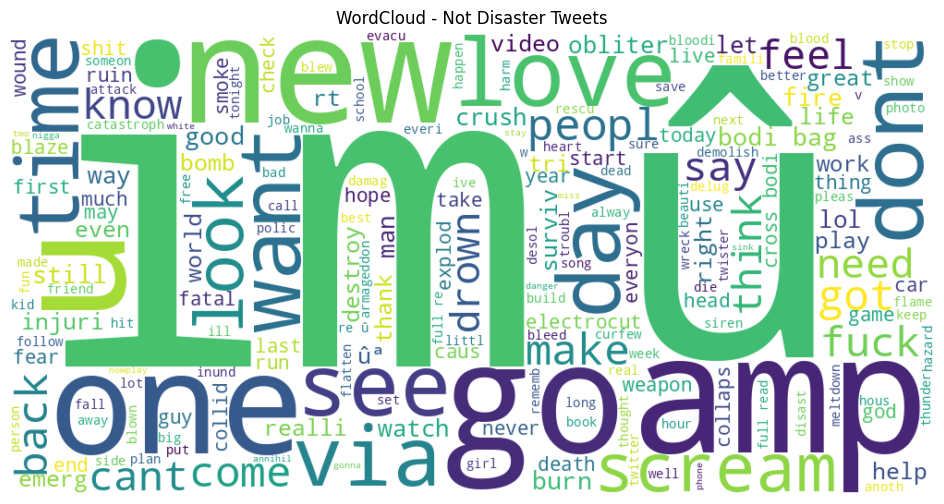

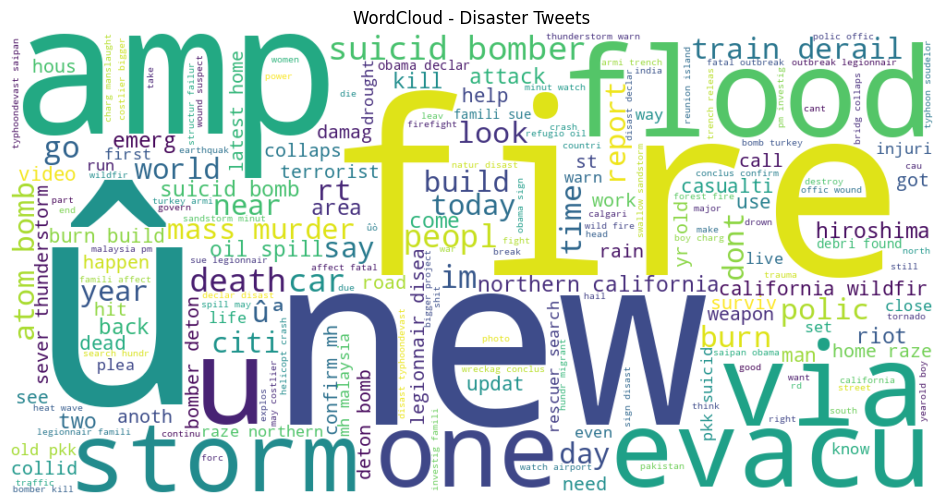

In [70]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Text for each class
not_disaster_text = " ".join(
    df[df["target"] == 0]["processed_text"]
)

disaster_text = " ".join(
    df[df["target"] == 1]["processed_text"]
)

# Generate WordClouds
not_disaster_wc = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(not_disaster_text)

disaster_wc = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(disaster_text)

# Not Disaster WordCloud
plt.figure(figsize=(12, 6))
plt.imshow(not_disaster_wc, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud - Not Disaster Tweets")
plt.show()

# Disaster WordCloud
plt.figure(figsize=(12, 6))
plt.imshow(disaster_wc, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud - Disaster Tweets")
plt.show()

In [71]:
# Collect model accuracies

model_results = pd.DataFrame({
    "Model": [
        "Naive Bayes - DTM",
        "Naive Bayes - TF-IDF",
        "XGBoost - TF-IDF",
        "GloVe - LSTM",
        "DistilBERT"
    ],
    "Accuracy": [
        accuracy_nb_dtm,
        accuracy_nb_tfidf,
        accuracy_xgb,
        lstm_test_accuracy,
        bert_results["eval_accuracy"]
    ]
})

model_results = model_results.sort_values(
    "Accuracy",
    ascending=False
).reset_index(drop=True)

print(model_results)

                  Model  Accuracy
0            DistilBERT  0.835194
1     Naive Bayes - DTM  0.816152
2  Naive Bayes - TF-IDF  0.814839
3          GloVe - LSTM  0.803677
4      XGBoost - TF-IDF  0.776756


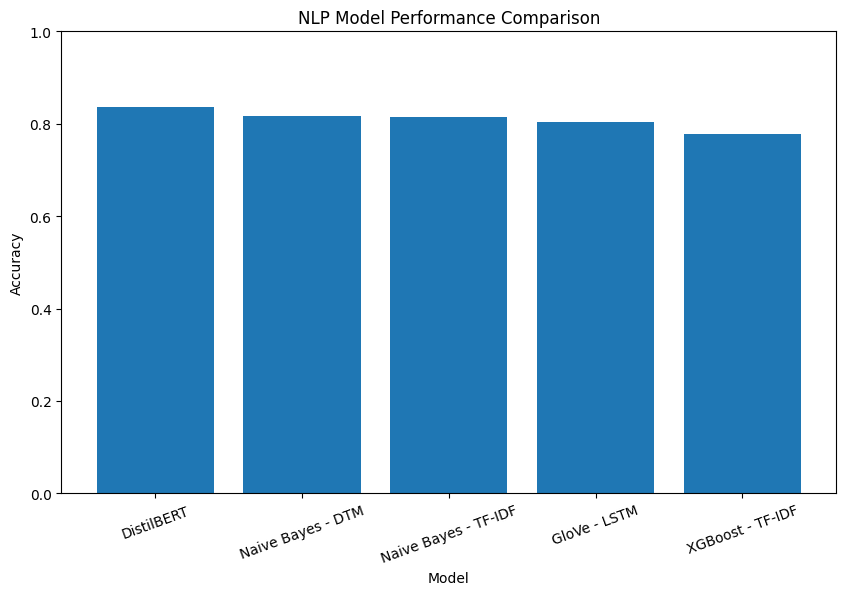

In [72]:
plt.figure(figsize=(10, 6))

plt.bar(
    model_results["Model"],
    model_results["Accuracy"]
)

plt.title("NLP Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=20)

plt.show()

In [73]:
print("GloVe Embedding Matrix:")
print("Shape:", embedding_matrix.shape)

print("\nTraining data:")
print("Shape:", X_train_pad.shape)

print("\nTesting data:")
print("Shape:", X_test_pad.shape)

print("\nEmbedding dimension:", embedding_dim)
print("Maximum sequence length:", max_length)

GloVe Embedding Matrix:
Shape: (10000, 100)

Training data:
Shape: (6090, 23)

Testing data:
Shape: (1523, 23)

Embedding dimension: 100
Maximum sequence length: 23


In [74]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

glove_lstm_model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False
    ),

    LSTM(64),

    Dropout(0.5),

    Dense(32, activation="relu"),

    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

glove_lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

glove_lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

In [75]:
early_stopping_glove = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history_glove_lstm = glove_lstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stopping_glove],
    verbose=1
)

Epoch 1/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.7186 - loss: 0.5772 - val_accuracy: 0.7693 - val_loss: 0.4992
Epoch 2/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7785 - loss: 0.5030 - val_accuracy: 0.7635 - val_loss: 0.5022
Epoch 3/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7867 - loss: 0.4824 - val_accuracy: 0.7742 - val_loss: 0.4802
Epoch 4/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7997 - loss: 0.4680 - val_accuracy: 0.7898 - val_loss: 0.4800
Epoch 5/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8062 - loss: 0.4512 - val_accuracy: 0.7824 - val_loss: 0.4756
Epoch 6/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8190 - loss: 0.4314 - val_accuracy: 0.7767 - val_loss: 0.5127
Epoch 7/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8311 - loss: 0.4118 - val_accuracy: 0.7857 - val_loss: 0.4896


In [76]:
glove_lstm_loss, glove_lstm_accuracy = glove_lstm_model.evaluate(
    X_test_pad,
    y_test,
    verbose=0
)

print("GloVe + LSTM Test Loss:", glove_lstm_loss)
print("GloVe + LSTM Test Accuracy:", glove_lstm_accuracy)

GloVe + LSTM Test Loss: 0.46301940083503723
GloVe + LSTM Test Accuracy: 0.7931713461875916


In [77]:
from sklearn.metrics import classification_report, confusion_matrix

# Predict probabilities
y_pred_glove_prob = glove_lstm_model.predict(X_test_pad)

# Convert probabilities to classes
y_pred_glove = (y_pred_glove_prob >= 0.5).astype(int).ravel()

print("GloVe + LSTM Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_glove,
        target_names=["Not Disaster", "Disaster"]
    )
)

print("GloVe + LSTM Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_glove))

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
GloVe + LSTM Classification Report:
              precision    recall  f1-score   support

Not Disaster       0.80      0.85      0.82       869
    Disaster       0.78      0.72      0.75       654

    accuracy                           0.79      1523
   macro avg       0.79      0.78      0.79      1523
weighted avg       0.79      0.79      0.79      1523

GloVe + LSTM Confusion Matrix:
[[735 134]
 [181 473]]


In [78]:
final_results = pd.DataFrame({
    "Model": [
        "Naive Bayes - DTM",
        "Naive Bayes - TF-IDF",
        "XGBoost - TF-IDF",
        "GloVe + LSTM",
        "DistilBERT"
    ],
    "Accuracy": [
        accuracy_nb_dtm,
        accuracy_nb_tfidf,
        accuracy_xgb,
        glove_lstm_accuracy,
        bert_results["eval_accuracy"]
    ]
})

final_results = final_results.sort_values(
    "Accuracy",
    ascending=False
).reset_index(drop=True)

print("Final Model Comparison")
print("=" * 50)
print(final_results.to_string(index=False))

Final Model Comparison
               Model  Accuracy
          DistilBERT  0.835194
   Naive Bayes - DTM  0.816152
Naive Bayes - TF-IDF  0.814839
        GloVe + LSTM  0.793171
    XGBoost - TF-IDF  0.776756


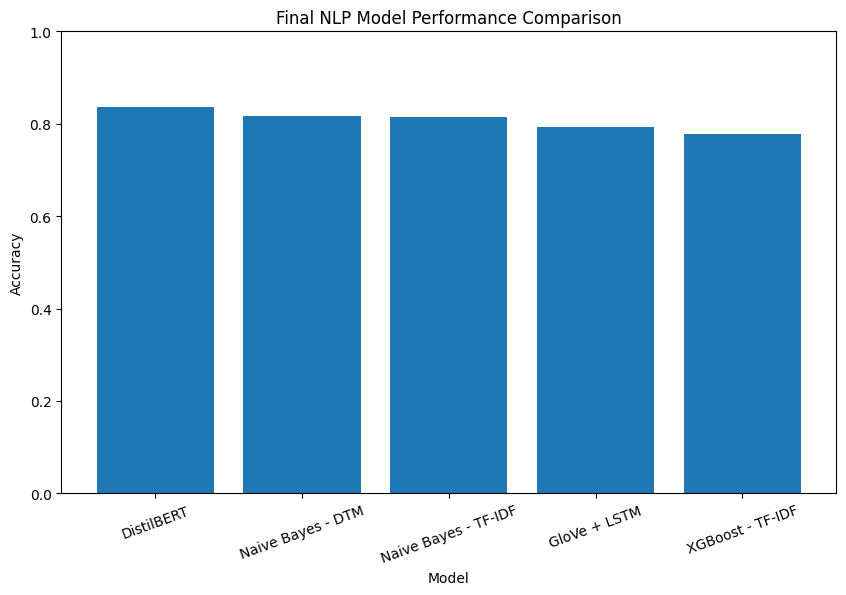

In [79]:
plt.figure(figsize=(10, 6))

plt.bar(
    final_results["Model"],
    final_results["Accuracy"]
)

plt.title("Final NLP Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=20)

plt.show()

In [80]:
print(final_results)

                  Model  Accuracy
0            DistilBERT  0.835194
1     Naive Bayes - DTM  0.816152
2  Naive Bayes - TF-IDF  0.814839
3          GloVe + LSTM  0.793171
4      XGBoost - TF-IDF  0.776756
